# Analisando Dados - Produção Hospitalar

## Pré-processamento de Dados

In [142]:
import pandas as pd

In [143]:
pd.options.display.float_format = '{:.2f}'.format

In [144]:
file_1 = 'A150850189_28_143_208.csv'
file_2 = 'A152918189_28_143_208.csv'

df = pd.read_csv(file_1, sep=';', encoding='ISO-8859-1', skiprows= 3, skipfooter=12, thousands='.', decimal=',', engine='python')

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Columns: 293 entries, Unidade da Federação to Total
dtypes: float64(170), object(123)
memory usage: 61.9+ KB


In [146]:
df.describe()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
count,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,...,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00
mean,304952.77,788145.26,2440162.96,5517354.05,12337159.42,76872923.93,23825025.66,25882844.71,26215278.28,26221049.45,...,57043175.42,58917158.65,59070927.95,81749309.03,81142931.26,87271862.20,77590406.47,60846287.01,43885716.30,6852320913.49
std,392806.00,1071747.56,3421972.10,7767711.29,16345863.65,203345357.97,34476004.08,34826830.50,34796463.86,35071861.23,...,71812939.93,75886774.58,74250282.54,104151498.28,103731994.30,113210161.00,103596516.21,82898209.94,62018534.41,9169866693.74
min,4113.76,11858.63,43852.67,226661.18,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,2841469.69,2786277.13,2664375.13,3960131.30,4192540.54,3681417.80,3458187.11,2302711.01,1196754.85,337181964.14
25%,46580.42,139423.94,505778.42,1410610.81,3650090.00,8257222.37,7932273.51,8926011.35,8764559.62,9229049.70,...,19073133.75,19522001.10,20977269.17,29399477.97,26964958.13,27262112.33,24095597.98,18724376.30,11348430.84,2224263694.82
50%,179395.82,418053.58,1152115.25,2406035.32,5949408.99,16599004.84,10215956.80,12262049.08,12453466.98,11900817.00,...,29093489.77,27452425.03,28344652.94,37147348.21,38411419.09,41819897.10,34937134.14,29364200.76,20837865.89,2867428082.03
75%,392985.52,969999.75,2625635.63,5915821.61,13394973.35,52156843.27,26932691.98,30400866.02,30982776.89,31307258.67,...,79372320.79,79191784.05,81887992.15,100967867.00,108236362.28,117460819.75,106300830.46,79844137.72,55265343.61,8818298482.19
max,1665349.90,4434168.64,14577395.84,35032259.98,76668547.41,1049827695.26,173062308.33,170621304.31,170389849.75,172513744.39,...,338634303.39,361427087.80,352846447.86,502905607.53,504427182.45,548112705.83,503160959.54,404373175.61,301986341.98,44290790025.14


## Aula 4 - Análise de gráficos e criação de hipóteses

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [148]:
df.replace('-', np.nan, inplace=True)
df.dropna(axis=1, inplace=True)
df.set_index('Unidade da Federação', inplace=True)
df.sort_values(by='Total', ascending=False, inplace=True)
df.drop(columns='Total',axis= 1, inplace=True)

In [149]:
df = df.iloc[:, 6:]

In [150]:
df.head()

,2008/Fev,2008/Mar,2008/Abr,2008/Mai,2008/Jun,2008/Jul,2008/Ago,2008/Set,2008/Out,2008/Nov,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
35 São Paulo,173062308.33,170621304.31,170389849.75,172513744.39,175557604.00,179608674.95,180097396.03,180211608.05,191999377.14,191258107.41,...,328687791.75,338634303.39,361427087.80,352846447.86,502905607.53,504427182.45,548112705.83,503160959.54,404373175.61,301986341.98
31 Minas Gerais,70301089.50,79119005.51,79046322.41,79268070.12,79628284.54,82216960.75,80374117.08,82416883.07,88613476.60,84486996.11,...,172730921.65,181833354.32,192844182.05,183891512.07,261376726.91,255545757.83,275151838.35,249713866.70,194734136.81,139157823.59
41 Paraná,48855046.46,55611791.07,56115135.82,55574831.93,56094754.74,59802402.07,56699001.13,58091985.79,61365941.22,59667208.62,...,135278692.53,129212815.78,130532844.63,134077150.52,172636232.13,174040312.61,191861617.22,163580936.16,119408026.56,91187722.64
43 Rio Grande do Sul,45897704.82,52928695.92,51972416.77,51679350.79,53759674.01,56391647.77,56233758.74,57910170.98,59592124.91,57565742.08,...,117696633.24,120291289.00,115991861.17,126730284.94,169687680.33,145302546.19,155084262.06,142812283.70,112805351.92,74954589.62
33 Rio de Janeiro,44128159.73,42907909.35,45315594.87,43951349.46,44118169.60,44360299.24,42502172.22,43066461.47,44553314.55,41351511.51,...,83923869.68,96752689.81,103468410.54,87518760.94,125735135.97,132965058.07,145372684.38,124909043.81,113660882.20,94137361.39


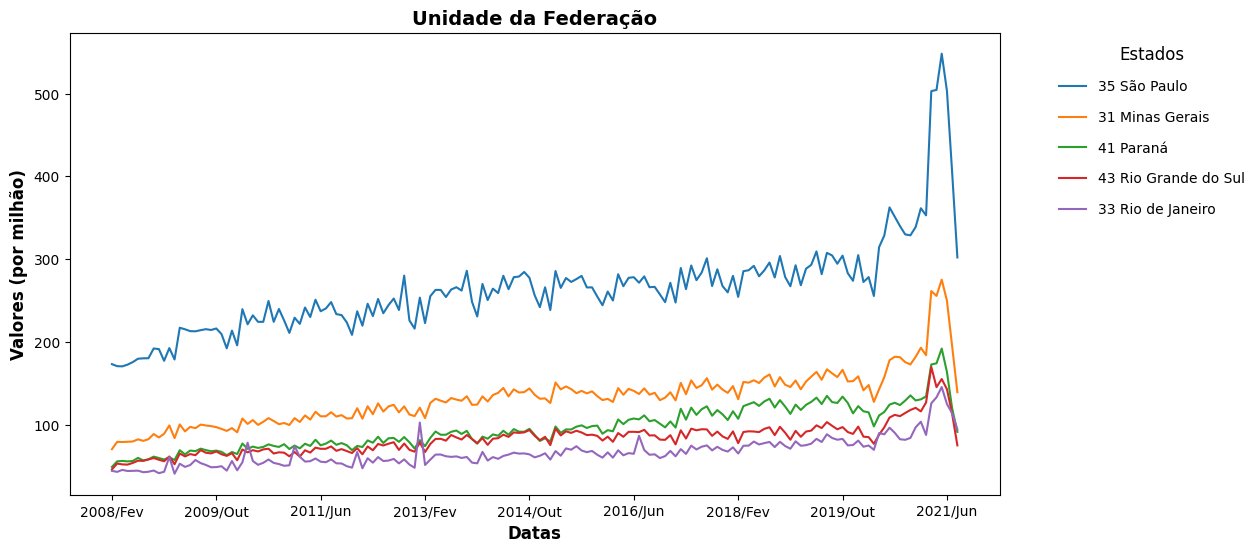

In [151]:
df = df / 1_000_000

ax = df.head().T.plot(figsize=(12,6))

plt.title('Unidade da Federação', fontsize=14, fontweight='bold')

ax.set_ylabel('Valores (por milhão)', fontsize=12, fontweight='bold')
ax.set_xlabel('Datas',fontsize=12, fontweight='bold')

plt.legend(title='Estados', title_fontsize=12, labelspacing=1.2, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(1.05, 1))

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [152]:
def plota_gastos_p_mes(data, figsize):
    axis = df.head(data).T.plot(figsize=figsize)
    axis.set_ylabel('Valores (por milhão)', fontsize=12, fontweight='bold')
    axis.set_xlabel('Datas',fontsize=12, fontweight='bold')

(0.0, 600.0)

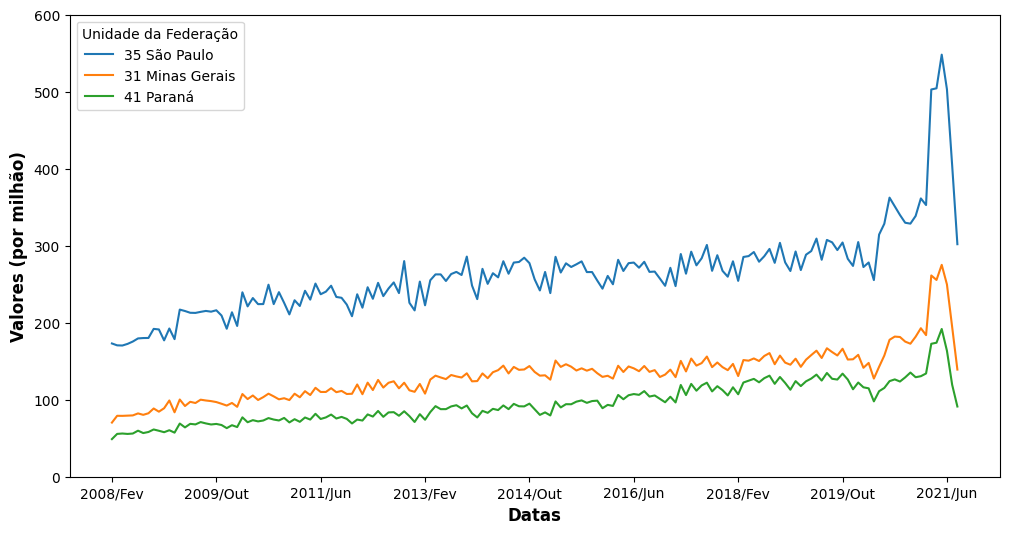

In [153]:
plota_gastos_p_mes(3, (12,6))
plt.ylim(0, 600)

## Desafio

> Padronizar os ticks verticais para espaçamento  de 12 e 12 unidades (uma vez ao ano).

> Escolher e utilizar outras cores.

> Colocar uma grade (grid) horizontal e vertical.

In [ ]:
def plota_gastos_p_mes(data, figsize):
    # Mudando o estilo do gráfico para dark
    plt.style.use('dark_background')

    # Configurando como minha função vai funcionar
    axis = df.head(data).T.plot(figsize=figsize)

    #Título do gráfico
    plt.title('Unidade da Federação', fontsize=14, fontweight='bold')

    # Colocando nomes nas linhas do eixo Y
    axis.set_ylabel('Valores (por milhão)', fontsize=12, fontweight='bold')
    axis.set_xlabel('Datas',fontsize=12, fontweight='bold')

    # Personalizando legenda
    plt.legend(title='Estados', title_fontsize=12, labelspacing=1.2, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(1.05, 1))

    # Adicionando grid na tabela
    axis.grid(color='white', linestyle='--', alpha=0.7)

   # Configurando os ticks no eixo X para aparecer de 12 em 12 meses
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%b'))  # Formato '2008/Jan'




(0.0, 600.0)

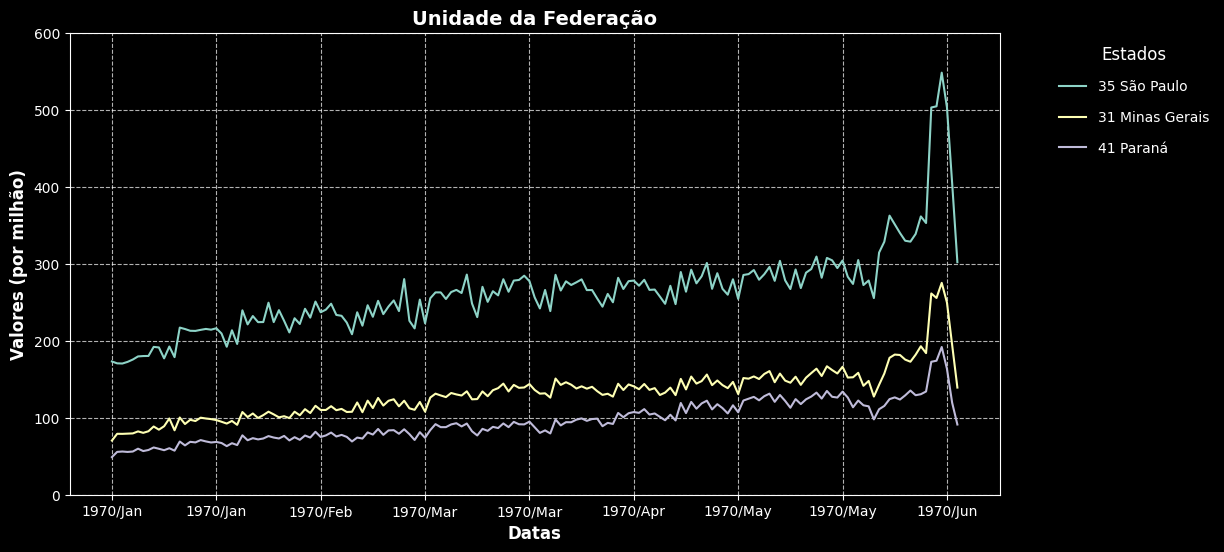

In [163]:
plota_gastos_p_mes(3, (12,6))
plt.ylim(0, 600)